<a href="https://colab.research.google.com/github/ilinkabibic/Tom-and-Jerry-Character-Classification/blob/main/notebooks/03_klasican_ml_blagoje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Klasičan ML: Random Forest (Blagoje)

Klasifikacija likova iz crtaća *Tom i Džeri* u 4 klase: **tom**, **jerry**,
**both** (oba lika), **neither** (nijedan).

Ovo je **klasičan ML** model (**Random Forest**). Radi nad **ručno dizajniranim
osobinama** (HOG + histogrami boja, ukupno **1860** po slici), koje su izvučene iz
slika i snimljene u `features_hog_color.npy`. Koristi **istu podelu**
(`data_split.csv`) kao svi ostali modeli — radi poštenog poređenja.

- **Osobine:** HOG (oblici/ivice) + histogrami boja
- **Model:** Random Forest (`class_weight='balanced'` zbog neizbalansiranih klasa)
- **Izbor modela:** na **validacionom** skupu, po **macro-F1**
- **Test skup:** ne dira se ovde — evaluira se jednom, na kraju, za sve modele

In [1]:
!git clone https://github.com/ilinkabibic/Tom-and-Jerry-Character-Classification repo
!cp repo/features_hog_color.npy repo/data_split.csv .
!ls -la features_hog_color.npy data_split.csv

Cloning into 'repo'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 31 (delta 11), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 29.79 MiB | 12.75 MiB/s, done.
Resolving deltas: 100% (11/11), done.
-rw-r--r-- 1 root root   159127 Aug 22 17:54 data_split.csv
-rw-r--r-- 1 root root 40756448 Aug 22 17:54 features_hog_color.npy


In [2]:
import numpy as np
import pandas as pd

X = np.load('features_hog_color.npy')      # matrica osobina, isti redosled kao data_split.csv
split_df = pd.read_csv('data_split.csv')    # kolone: filename, tom, jerry, class, split

print('X shape:', X.shape)                  # ocekujemo (5478, 1860)
print('split_df shape:', split_df.shape)

assert X.shape[0] == split_df.shape[0], 'Broj redova se ne poklapa!'

y = split_df['class'].values

train_mask = split_df['split'].values == 'train'
val_mask   = split_df['split'].values == 'val'
test_mask  = split_df['split'].values == 'test'

X_train, y_train = X[train_mask], y[train_mask]
X_val,   y_val   = X[val_mask],   y[val_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print('train:', X_train.shape, '| val:', X_val.shape, '| test:', X_test.shape)

X shape: (5478, 1860)
split_df shape: (5478, 5)
train: (3778, 1860) | val: (850, 1860) | test: (850, 1860)


Val accuracy: 0.5412
Val macro-F1: 0.4667

              precision    recall  f1-score   support

        both       0.82      0.37      0.51       115
       jerry       0.68      0.11      0.19       203
     neither       0.41      0.54      0.47       218
         tom       0.58      0.88      0.70       314

    accuracy                           0.54       850
   macro avg       0.62      0.48      0.47       850
weighted avg       0.59      0.54      0.49       850



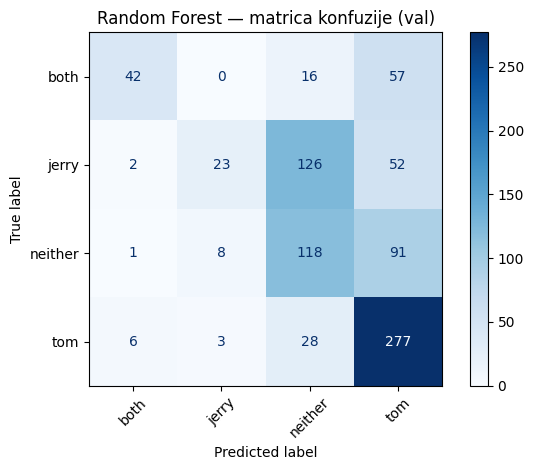

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

# 1) napravi model
rf = RandomForestClassifier(
    n_estimators=300,          # broj stabala u "sumi"
    class_weight='balanced',   # zbog neizbalansiranih klasa
    random_state=42,           # ponovljivost (isti rezultat pri svakom pokretanju)
    n_jobs=-1)                 # koristi sva jezgra procesora (brze)

# 2) treniraj na TRAIN skupu (Random Forest-u NE treba StandardScaler)
rf.fit(X_train, y_train)

# 3) predvidi na VAL skupu (test se ne dira do kraja)
val_pred = rf.predict(X_val)

# 4) mere
print('Val accuracy:', round(accuracy_score(y_val, val_pred), 4))
print('Val macro-F1:', round(f1_score(y_val, val_pred, average='macro'), 4))
print()
print(classification_report(y_val, val_pred))

# 5) matrica konfuzije
labels = sorted(np.unique(y))
cm = confusion_matrix(y_val, val_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap='Blues', xticks_rotation=45)
plt.title('Random Forest — matrica konfuzije (val)')
plt.tight_layout()
plt.show()

In [4]:
from sklearn.metrics import f1_score

# probamo par podesavanja i biramo najbolje po macro-F1 na VAL skupu
kandidati = [
    dict(n_estimators=300, max_depth=None, min_samples_leaf=1),  # trenutni
    dict(n_estimators=600, max_depth=None, min_samples_leaf=1),
    dict(n_estimators=600, max_depth=30,   min_samples_leaf=1),
    dict(n_estimators=600, max_depth=None, min_samples_leaf=2),
    dict(n_estimators=800, max_depth=None, min_samples_leaf=1),
]

najbolji_f1, najbolji_par, najbolji_model = -1, None, None
for p in kandidati:
    m = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, **p)
    m.fit(X_train, y_train)
    f1 = f1_score(y_val, m.predict(X_val), average='macro')
    print(p, '-> val macro-F1:', round(f1, 4))
    if f1 > najbolji_f1:
        najbolji_f1, najbolji_par, najbolji_model = f1, p, m

print('\nNAJBOLJI:', najbolji_par, '| val macro-F1:', round(najbolji_f1, 4))

{'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4667
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4634
{'n_estimators': 600, 'max_depth': 30, 'min_samples_leaf': 1} -> val macro-F1: 0.4634
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 2} -> val macro-F1: 0.4768
{'n_estimators': 800, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4526

NAJBOLJI: {'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 2} | val macro-F1: 0.4768


In [5]:
from sklearn.metrics import f1_score

# probamo par podesavanja i biramo najbolje po macro-F1 na VAL skupu
kandidati = [
    dict(n_estimators=300, max_depth=None, min_samples_leaf=1),  # trenutni
    dict(n_estimators=600, max_depth=None, min_samples_leaf=1),
    dict(n_estimators=600, max_depth=30,   min_samples_leaf=1),
    dict(n_estimators=600, max_depth=None, min_samples_leaf=2),
    dict(n_estimators=800, max_depth=None, min_samples_leaf=1),
]

najbolji_f1, najbolji_par, najbolji_model = -1, None, None
for p in kandidati:
    m = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1, **p)
    m.fit(X_train, y_train)
    f1 = f1_score(y_val, m.predict(X_val), average='macro')
    print(p, '-> val macro-F1:', round(f1, 4))
    if f1 > najbolji_f1:
        najbolji_f1, najbolji_par, najbolji_model = f1, p, m

print('\nNAJBOLJI:', najbolji_par, '| val macro-F1:', round(najbolji_f1, 4))

{'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4667
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4634
{'n_estimators': 600, 'max_depth': 30, 'min_samples_leaf': 1} -> val macro-F1: 0.4634
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 2} -> val macro-F1: 0.4768
{'n_estimators': 800, 'max_depth': None, 'min_samples_leaf': 1} -> val macro-F1: 0.4526

NAJBOLJI: {'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 2} | val macro-F1: 0.4768


Val accuracy: 0.5494
Val macro-F1: 0.4768

              precision    recall  f1-score   support

        both       0.80      0.38      0.52       115
       jerry       0.75      0.12      0.20       203
     neither       0.41      0.56      0.47       218
         tom       0.60      0.88      0.71       314

    accuracy                           0.55       850
   macro avg       0.64      0.49      0.48       850
weighted avg       0.61      0.55      0.50       850



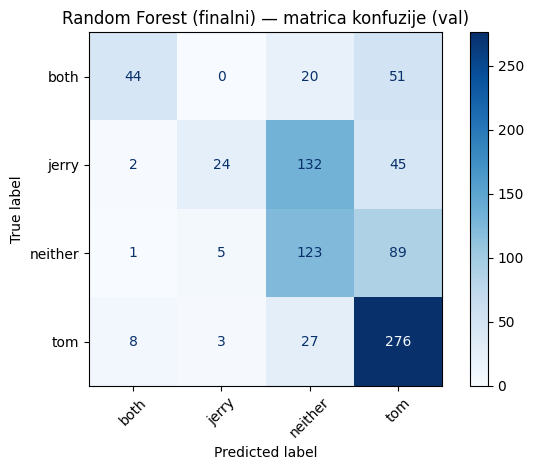

In [6]:
# Finalni Random Forest (najbolje podesavanje nadjeno na val skupu)
rf_final = RandomForestClassifier(
    n_estimators=600, max_depth=None, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1)
rf_final.fit(X_train, y_train)

val_pred = rf_final.predict(X_val)
print('Val accuracy:', round(accuracy_score(y_val, val_pred), 4))
print('Val macro-F1:', round(f1_score(y_val, val_pred, average='macro'), 4))
print()
print(classification_report(y_val, val_pred))

labels = sorted(np.unique(y))
cm = confusion_matrix(y_val, val_pred, labels=labels)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
    cmap='Blues', xticks_rotation=45)
plt.title('Random Forest (finalni) — matrica konfuzije (val)')
plt.tight_layout(); plt.show()
